<a href="https://colab.research.google.com/github/keertish05/big_data_project/blob/main/PS2_groupbased_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic data...
Demographics CSV created successfully!
Creating medical test results JSON...
Medical tests JSON created successfully!
First line of JSON file: {"test_id": "T5001", "patient_id": "P1474", "test_name": "Influenza A", "result_value": "negative", "units": "", "test_date": "2025-10-28"}

Loading data...
Demographics schema:
root
 |-- patient_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- city: string (nullable = true)
 |-- zip_code: integer (nullable = true)

Test results schema:
root
 |-- test_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- test_name: string (nullable = true)
 |-- result_value: string (nullable = true)
 |-- units: string (nullable = true)
 |-- test_date: string (nullable = true)

Demographics count: 500
Test results count: 1200
Sample demographics:
+----------+---+------+---------+--------+
|patient_id|age|gender|     city|zip_code|
+----------+---+------+-

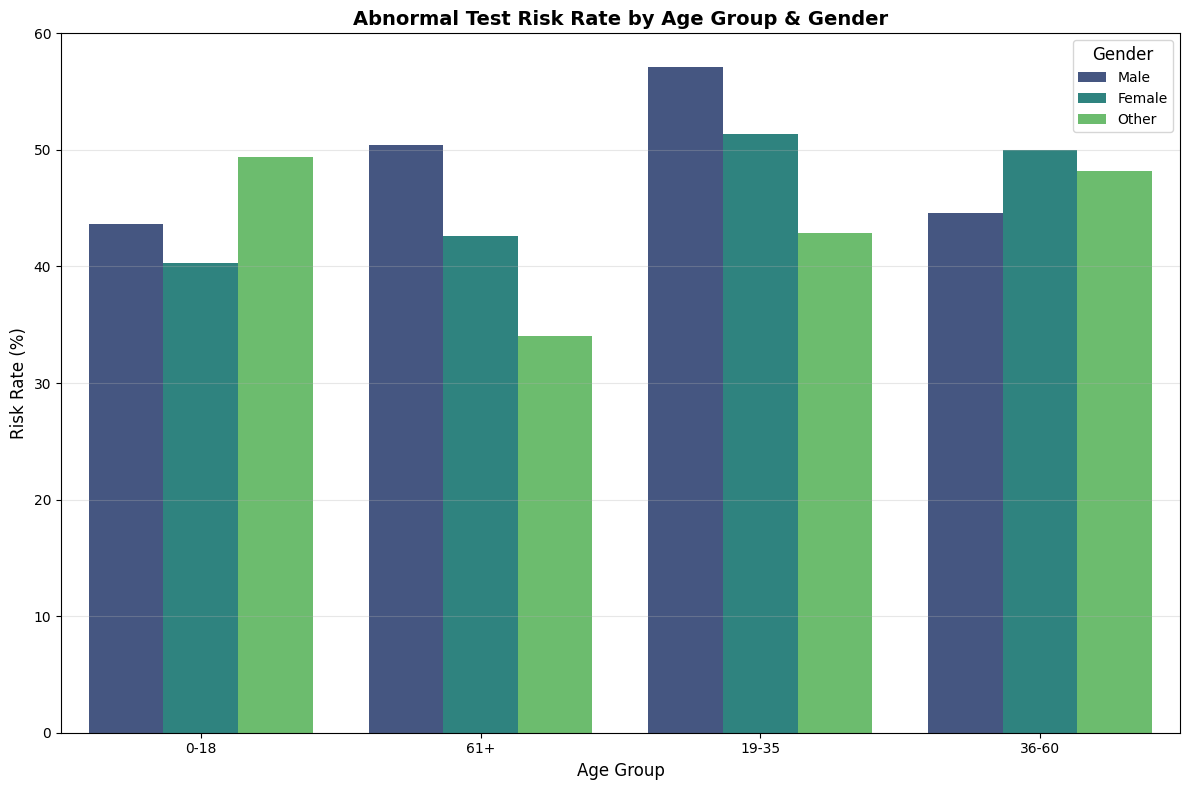


Final Results Table:
Age_group gender  total_tests  abnormal_count  risk_rate
     0-18   Male           71              31  43.661972
      61+   Male          121              61  50.413223
     0-18 Female           77              31  40.259740
     0-18  Other           79              39  49.367089
    19-35  Other           70              30  42.857143
    36-60  Other          135              65  48.148148
    19-35 Female           72              37  51.388889
    36-60 Female          138              69  50.000000
    19-35   Male          105              60  57.142857
    36-60   Male           83              37  44.578313
      61+  Other           94              32  34.042553
      61+ Female          155              66  42.580645

Summary Statistics:
Total tests analyzed: 1200
Total abnormal tests: 558
Overall abnormal rate: 46.50%

Abnormal tests by test type:
+-------------+-----+
|    test_name|count|
+-------------+-----+
|    COVID PCR|  214|
|  Influenza A|

In [ ]:
# Install required packages
!pip install pyspark

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, sum as spark_sum, lit, udf
from pyspark.sql.types import FloatType, StringType, StructType, StructField
import json
import random
from datetime import datetime, timedelta

# Generate synthetic data first with proper JSON formatting
print("Generating synthetic data...")

# Basic pools for data
cities = ["Delhi", "Mumbai", "Chennai", "Bangalore"]
genders = ["Male", "Female", "Other"]
test_names = ["COVID PCR", "Blood Glucose", "Influenza A"]

# 1. Patient Demographics (CSV)
demographics_data = []
for i in range(1, 501):  # 500 patients
    age = random.randint(1, 85)
    city = random.choice(cities)
    zip_code = random.randint(100000, 999999)
    gender = random.choice(genders)
    pid = f"P{1000 + i}"
    demographics_data.append([pid, age, gender, city, zip_code])

# Create demographics DataFrame and save as CSV
demographics_df = pd.DataFrame(demographics_data,
                              columns=["patient_id", "age", "gender", "city", "zip_code"])
demographics_df.to_csv("demographics.csv", index=False)
print("Demographics CSV created successfully!")

# 2. Medical Test Results (JSON) - Create line-delimited JSON
print("Creating medical test results JSON...")
medical_test_results = []

for i in range(1, 1201):  # 1200 tests
    test_date = (datetime.now() - timedelta(days=random.randint(0, 30))).strftime("%Y-%m-%d")
    patient_id, age, gender, city, zip_code = random.choice(demographics_data)
    test_name = random.choice(test_names)

    if test_name == "Blood Glucose":
        result = round(random.uniform(70, 200), 1)
        units = "mg/dl"
    elif test_name == "COVID PCR":
        result = random.choice(["positive", "negative"])
        units = ""
    else:  # Influenza A
        result = random.choice(["positive", "negative"])
        units = ""

    obj = {
        "test_id": f"T{5000 + i}",
        "patient_id": patient_id,
        "test_name": test_name,
        "result_value": str(result),
        "units": units,
        "test_date": test_date
    }
    medical_test_results.append(obj)

# Write as line-delimited JSON (one JSON object per line)
with open("medical_tests.json", "w") as f:
    for record in medical_test_results:
        json.dump(record, f)
        f.write('\n')

print("Medical tests JSON created successfully!")

# Verify the JSON file
with open("medical_tests.json", "r") as f:
    first_line = f.readline()
    print("First line of JSON file:", first_line)

# Start SparkSession
spark = SparkSession.builder.appName("PS2_Risk_Profiling").getOrCreate()

# Define schema for medical tests to help Spark parse correctly
medical_tests_schema = StructType([
    StructField("test_id", StringType(), True),
    StructField("patient_id", StringType(), True),
    StructField("test_name", StringType(), True),
    StructField("result_value", StringType(), True),
    StructField("units", StringType(), True),
    StructField("test_date", StringType(), True)
])

# 1. Load Data (Structured: DataFrame)
print("Loading data...")
demographics = spark.read.csv("demographics.csv", header=True, inferSchema=True)
demographics.cache()

# Load JSON with explicit schema and multiLine=False for line-delimited JSON
test_results = spark.read.option("multiLine", "false").json("medical_tests.json", schema=medical_tests_schema)
test_results.cache()

print("Demographics schema:")
demographics.printSchema()
print("Test results schema:")
test_results.printSchema()

print(f"Demographics count: {demographics.count()}")
print(f"Test results count: {test_results.count()}")

# Show sample data
print("Sample demographics:")
demographics.show(5)
print("Sample test results:")
test_results.show(5)

# 2. Join on patient_id
print("Joining datasets...")
merged = test_results.join(demographics, on='patient_id', how='inner').cache()
print(f"Merged data count: {merged.count()}")
merged.show(5)

# 3. Create Age_group Column
print("Creating age groups...")

def age_group(age):
    if age is None:
        return None
    if age <= 18:
        return "0-18"
    elif age <= 35:
        return "19-35"
    elif age <= 60:
        return "36-60"
    else:
        return "61+"

age_group_udf = udf(age_group, StringType())
merged = merged.withColumn("Age_group", age_group_udf(col("age")))

# 4. Flag Abnormal Test Results (thresholds)
print("Flagging abnormal results...")

def abnormal_flag(test_name, result_value):
    try:
        if test_name == "COVID PCR" and result_value == "positive":
            return 1
        elif test_name == "Blood Glucose" and float(result_value) > 150:
            return 1
        elif test_name == "Influenza A" and result_value == "positive":
            return 1
        else:
            return 0
    except:
        return 0

abnormal_udf = udf(abnormal_flag, StringType())
merged = merged.withColumn("abnormal_flag", abnormal_udf(col("test_name"), col("result_value")).cast("int"))

# Show some sample data with flags
print("Sample of merged data with flags:")
merged.select("patient_id", "age", "Age_group", "gender", "test_name", "result_value", "abnormal_flag").show(10)

# Check abnormal flag distribution
print("Abnormal flag distribution:")
merged.groupBy("abnormal_flag").count().show()

# 5. Aggregate Counts and Calculate Risk Rate
print("Aggregating data...")
agg = merged.groupBy("Age_group", "gender").agg(
    count("test_name").alias("total_tests"),
    spark_sum("abnormal_flag").alias("abnormal_count")
)
agg = agg.withColumn("risk_rate", (col("abnormal_count") / col("total_tests")) * 100)

print("Aggregated results:")
agg.show()

# Handle any potential division by zero or null values
agg = agg.fillna(0)

# Convert to Pandas for plotting
agg_pd = agg.toPandas()
agg_pd.to_csv("ps2_risk_profile.csv", index=False)

print("Aggregated data saved to ps2_risk_profile.csv")

# 6. Create Visualization
print("Creating visualization...")
plt.figure(figsize=(12, 8))

# Create bar plot
sns.barplot(data=agg_pd, x='Age_group', y='risk_rate', hue='gender', palette='viridis')
plt.ylabel("Risk Rate (%)", fontsize=12)
plt.xlabel("Age Group", fontsize=12)
plt.title("Abnormal Test Risk Rate by Age Group & Gender", fontsize=14, fontweight='bold')
plt.legend(title='Gender', title_fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("ps2_stacked_bar_chart.png", dpi=300, bbox_inches='tight')
plt.show()

# Display the results table
print("\nFinal Results Table:")
print(agg_pd.to_string(index=False))

# Additional summary statistics
print("\nSummary Statistics:")
total_tests = merged.count()
abnormal_tests = merged.filter(col('abnormal_flag') == 1).count()
print(f"Total tests analyzed: {total_tests}")
print(f"Total abnormal tests: {abnormal_tests}")
print(f"Overall abnormal rate: {(abnormal_tests/total_tests)*100:.2f}%")

# Show distribution by test type
print("\nAbnormal tests by test type:")
merged.filter(col('abnormal_flag') == 1).groupBy('test_name').count().show()

# Stop SparkSession
spark.stop()

print("\nPipeline completed successfully!")
print("Output files:")
print("- ps2_risk_profile.csv: Aggregated risk profile data")
print("- ps2_stacked_bar_chart.png: Visualization chart")